<style>
.jp-RenderedHTMLCommon,
.text_cell_render {
  font-family: medium-content-serif-font, Georgia, Cambria, "Times New Roman", Times, serif;
  font-size: 17px;
  line-height: 1.65;
  color: #1f2328;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.text_cell_render h1,
.text_cell_render h2,
.text_cell_render h3 {
  font-family: sohne, "Helvetica Neue", Helvetica, Arial, sans-serif;
  color: #111;
}
.jp-RenderedHTMLCommon h1,
.text_cell_render h1 {
  font-size: 2.6rem;
  letter-spacing: -0.03em;
}
.jp-RenderedHTMLCommon h2,
.text_cell_render h2 {
  margin-top: 1.8em;
}
</style>

# Expediente D. Contrato que crece

Data Analytics | Semanas 7–8 | 2026-2

Este notebook acompaña la lectura ¿Qué puede decir realmente un contrato público?

Afirmación que se investigará:

Algunas características observables de los contratos están asociadas con la presencia posterior de registros de adición.

Este expediente utiliza dos archivos: `data/secop_recorte.csv` y `data/secop_adiciones.csv`.

Durante la primera semana se construyen tres evidencias y se documentan tres decisiones de preparación. En la segunda semana se incorpora una objeción y se revisa si la conclusión inicial se mantiene.

El objetivo es que cada cifra utilizada en la conclusión pueda localizarse en el notebook y que el alcance de la afirmación corresponda a lo que realmente muestran los datos.


## Preparar los datos

Ubique el notebook junto a la carpeta `data`.

```text
Expediente_D.ipynb
data/
├── secop_recorte.csv
└── secop_adiciones.csv
```

`secop_recorte.csv` contiene los contratos asignados al equipo. `secop_adiciones.csv` contiene los registros de adición asociados con esos contratos.

No es necesario descargar datos, seleccionar un equipo ni modificar filtros.


In [ ]:
from pathlib import Path
from statistics import NormalDist
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CONTRACTS_FILE = Path("Data") / "secop_recorte.csv"
ADDITIONS_FILE = Path("Data") / "secop_adiciones.csv"

if not CONTRACTS_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_recorte.csv.")

if not ADDITIONS_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_adiciones.csv.")

df_raw = pd.read_csv(CONTRACTS_FILE, dtype=str)
adiciones_raw = pd.read_csv(ADDITIONS_FILE, dtype=str)

print("Contratos:", f"{len(df_raw):,}")
print("Registros de adición:", f"{len(adiciones_raw):,}")

Contratos: 30,777
Registros de adición: 50,000


## Comprender el archivo antes de analizarlo

Cada fila de `secop_recorte.csv` representa un contrato incluido en el conjunto asignado al equipo. El archivo no corresponde a todo SECOP II, sino a una parte previamente seleccionada para la actividad.

La columna `ciudad`, cuando está disponible, identifica la ciudad de registro de la entidad que publica el contrato. No debe interpretarse automáticamente como el lugar físico donde se ejecutó el servicio, la obra o el suministro.

Las siguientes conversiones permiten trabajar con valores y fechas sin eliminar registros.


In [ ]:
df = df_raw.copy()

for column in ["valor_del_contrato", "dias_adicionados"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

if {
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
}.issubset(df.columns):
    df["duracion_dias"] = (
        df["fecha_de_fin_del_contrato"]
        - df["fecha_de_inicio_del_contrato"]
    ).dt.days

if {"valor_del_contrato", "duracion_dias"}.issubset(df.columns):
    months = df["duracion_dias"] / 30.44
    df["valor_mensual_equivalente"] = (
        df["valor_del_contrato"] / months.where(months > 0)
    )

sample_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "tipo_de_contrato",
        "modalidad_de_contratacion",
        "valor_del_contrato",
        "fecha_de_firma",
    ]
    if c in df.columns
]

df[sample_columns].head()


,id_contrato,nombre_entidad,ciudad,proveedor_adjudicado,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato,fecha_de_firma
0,CO1.PCCNTR.8489358,GOBERNACIÓN DE BOYACÁ,Tunja,SEGA SERVICIOS INTEGRADOS DE INGENIERIA Y CONS...,Interventoría,Mínima cuantía,8452876.46,2025-10-30
1,CO1.PCCNTR.7393860,GOBERNACIÓN DE BOYACÁ,Tunja,maria miryam,Prestación de servicios,Contratación directa,37036534.00,2025-02-05
2,CO1.PCCNTR.7823737,MUNICIPIO DE TUTA,Tuta,Santiago alonso vargas camacho,Prestación de servicios,Contratación directa,1240000.00,2025-04-29
3,CO1.PCCNTR.8139299,CONCEJO MUNICIPAL DE TUNJA,Tunja,HERNAN GABRIEL ACOSTA ALVAREZ,Prestación de servicios,Contratación directa,10000000.00,2025-07-29
4,CO1.PCCNTR.6571520,GOBERNACIÓN DE BOYACÁ,Tunja,Alcaldía Municipal de Socha,Otro,Contratación Directa (con ofertas),44483870.20,2024-07-29


### Antes de seguir

1. ¿Qué representa una fila?

Una fila representa un contrato incluido dentro del recorte de datos asignado al equipo.

2. ¿Qué información permite identificar a la entidad y al proveedor?

El conjunto contiene variables como nombre_entidad, ciudad, proveedor_adjudicado y documento_proveedor, que permiten identificar o caracterizar a la entidad y al proveedor asociado al contrato.

3. ¿Qué variable monetaria aparece en el archivo?

La principal variable monetaria utilizada durante la primera semana fue valor_del_contrato, que representa el valor inicial registrado para cada contrato.

4. ¿Qué variable o columna necesita comprender mejor antes de utilizarla?

Una variable que requiere especial atención es ciudad, debido a que el notebook advierte que corresponde a la ciudad de registro de la entidad que publica el contrato y no necesariamente al lugar físico donde se ejecuta el contrato.

También fue necesario comprender id_contrato, ya que esta variable es fundamental para relacionar correctamente los contratos con las adiciones.


## Primera semana: describir el conjunto asignado

La primera revisión se concentra en `valor_del_contrato`. Se estudiará una variable por separado antes de introducir comparaciones entre grupos.

La media, la mediana y los percentiles no responden exactamente la misma pregunta. Si la distribución contiene unos pocos contratos de valor muy alto, la media puede alejarse considerablemente de la mediana.


In [ ]:
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

contract_value = df["valor_del_contrato"].dropna()

value_summary = pd.Series({
    "contratos con valor registrado": len(contract_value),
    "media": contract_value.mean(),
    "mediana": contract_value.median(),
    "percentil 25": contract_value.quantile(0.25),
    "percentil 75": contract_value.quantile(0.75),
    "percentil 90": contract_value.quantile(0.90),
    "mínimo": contract_value.min(),
    "máximo": contract_value.max(),
    "contratos con valor 0": int((contract_value == 0).sum()),
})

value_summary.to_frame("resultado")


,resultado
contratos con valor registrado,3.077700e+04
media,2.027747e+10
mediana,1.800000e+07
percentil 25,9.975000e+06
percentil 75,3.627775e+07
percentil 90,1.119626e+08
mínimo,0.000000e+00
máximo,6.207658e+14
contratos con valor 0,2.090000e+02


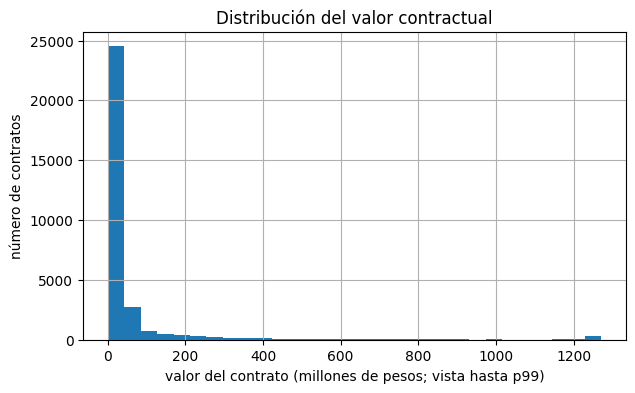

In [ ]:
upper_view = contract_value.quantile(0.99)

plt.figure(figsize=(7, 4))
(contract_value.clip(upper=upper_view) / 1_000_000).hist(bins=30)
plt.xlabel("valor del contrato (millones de pesos; vista hasta p99)")
plt.ylabel("número de contratos")
plt.title("Distribución del valor contractual")
plt.show()


### Deténgase y revise

1. ¿La media y la mediana son semejantes o muy diferentes?

Son muy diferentes. La media es aproximadamente 20.277 millones, mientras que la mediana es de aproximadamente $18 millones. Esta gran diferencia se debe principalmente a la presencia de contratos con valores extremadamente altos.

2. ¿Cuál de las dos describe mejor un contrato típico dentro de estos datos?

La mediana describe mejor un contrato típico, porque representa el valor central de los contratos y no se ve tan afectada por los valores extremos como la media.

3. ¿Qué muestra el histograma sobre la forma de la distribución?

El histograma muestra una distribución fuertemente sesgada hacia la derecha. La mayoría de los contratos se concentra en valores relativamente bajos, mientras que existe una cola larga hacia valores muy altos debido a algunos contratos de gran valor.

4. ¿Por qué limitar la escala visual al percentil 99 no equivale a eliminar esos contratos del análisis?

Porque únicamente se limita el rango que se muestra en el gráfico para que la distribución sea más fácil de visualizar. Los contratos que están por encima del percentil 99 siguen permaneciendo en el conjunto de datos y continúan participando en los cálculos estadísticos. No se están eliminando ni modificando; simplemente no se muestran en esa escala del histograma.


## Revisar la calidad antes de preparar los datos

Un faltante, un valor en cero, una repetición o un valor extremo no se elimina automáticamente. Primero debe establecerse si afecta la pregunta que se quiere responder.

La siguiente revisión muestra aspectos que pueden modificar las conclusiones.


In [ ]:
quality_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "documento_proveedor",
        "valor_del_contrato",
        "fecha_de_inicio_del_contrato",
        "fecha_de_fin_del_contrato",
        "duracion_dias",
    ]
    if c in df.columns
]

quality = pd.DataFrame({
    "faltantes": df[quality_columns].isna().sum(),
    "porcentaje_faltante": (df[quality_columns].isna().mean() * 100).round(1),
    "valores_unicos": df[quality_columns].nunique(dropna=True),
})

display(quality)

if "id_contrato" in df.columns:
    print(
        "IDs de contrato repetidos:",
        int(df["id_contrato"].duplicated(keep=False).sum())
    )

q1, q3 = df["valor_del_contrato"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr

print("Contratos con valor 0:", int((df["valor_del_contrato"] == 0).sum()))
print(
    "Posibles valores extremos según 1.5 × IQR:",
    int((df["valor_del_contrato"] > upper_iqr).sum())
)

if "duracion_dias" in df.columns:
    invalid_duration = (
        df["duracion_dias"].isna()
        | (df["duracion_dias"] <= 0)
    ).sum()
    print("Duraciones faltantes o no positivas:", int(invalid_duration))


,faltantes,porcentaje_faltante,valores_unicos
id_contrato,0,0.0,30777
nombre_entidad,0,0.0,311
ciudad,0,0.0,111
proveedor_adjudicado,0,0.0,16509
documento_proveedor,0,0.0,16478
valor_del_contrato,0,0.0,15232
fecha_de_inicio_del_contrato,175,0.6,735
fecha_de_fin_del_contrato,1,0.0,1110
duracion_dias,176,0.6,579


IDs de contrato repetidos: 0
Contratos con valor 0: 209
Posibles valores extremos según 1.5 × IQR: 3768
Duraciones faltantes o no positivas: 369


### Comprobar si una decisión cambia el resultado

Antes de decidir qué hacer con los valores en cero o con los contratos más altos, conviene observar cuánto cambia una estadística sencilla.

La siguiente comparación no prescribe una limpieza. Su función es mostrar si la mediana resulta sensible a tres formas distintas de preparar el valor contractual.


In [ ]:
medians = {}

all_values = df["valor_del_contrato"].dropna()
if len(all_values):
    medians["sin retirar ceros"] = all_values.median()

positive_values = df.loc[
    df["valor_del_contrato"] > 0,
    "valor_del_contrato"
].dropna()

if len(positive_values):
    medians["solo valores positivos"] = positive_values.median()

if len(positive_values):
    p99 = positive_values.quantile(0.99)
    below_p99 = positive_values[positive_values <= p99]
    medians["positivos, sin el 1 % superior"] = below_p99.median()

pd.Series(medians, name="mediana_valor")


,mediana_valor
sin retirar ceros,17890400.0
solo valores positivos,18000000.0
"positivos, sin el 1 % superior",17786000.0


### Tres decisiones de preparación

Documente tres decisiones que realmente se desprendan de sus datos. Para cada una, responda:

1. ¿Qué situación encontró?
2. ¿Qué tratamiento decidió aplicar?
3. ¿Qué salida del notebook respalda la decisión?
4. ¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?

No es necesario que todos los equipos adopten las mismas decisiones.


## Relacionar contratos y adiciones

Los dos archivos se relacionan mediante `id_contrato`. En `secop_recorte.csv`, cada fila corresponde a un contrato. En `secop_adiciones.csv`, un mismo contrato puede aparecer más de una vez porque puede tener varios registros de adición.

Por esta razón, primero se cuentan los registros de adición por contrato y después se incorpora ese resultado al archivo principal.


In [ ]:
if "id_contrato" not in df.columns:
    raise KeyError("secop_recorte.csv no contiene id_contrato.")

if "id_contrato" not in adiciones_raw.columns:
    raise KeyError("secop_adiciones.csv no contiene id_contrato.")

adiciones = adiciones_raw.copy()

if "fecharegistro" in adiciones.columns:
    adiciones["fecharegistro"] = pd.to_datetime(
        adiciones["fecharegistro"],
        errors="coerce"
    )

if "identificador" in adiciones.columns:
    additions_by_contract = (
        adiciones.groupby("id_contrato")
                 .agg(
                     numero_adiciones=("identificador", "nunique"),
                     ultima_adicion=("fecharegistro", "max")
                     if "fecharegistro" in adiciones.columns
                     else ("identificador", "size"),
                 )
                 .reset_index()
    )
else:
    additions_by_contract = (
        adiciones.groupby("id_contrato")
                 .size()
                 .rename("numero_adiciones")
                 .reset_index()
    )

df = df.merge(
    additions_by_contract,
    on="id_contrato",
    how="left"
)

df["numero_adiciones"] = (
    pd.to_numeric(df["numero_adiciones"], errors="coerce")
      .fillna(0)
      .astype(int)
)

df["tuvo_adicion"] = df["numero_adiciones"] > 0

print(
    "Contratos con al menos un registro de adición:",
    int(df["tuvo_adicion"].sum())
)
print(
    "Porcentaje de contratos con al menos un registro de adición:",
    round(df["tuvo_adicion"].mean() * 100, 1),
    "%"
)

df[
    ["id_contrato", "valor_del_contrato", "numero_adiciones", "tuvo_adicion"]
].head()


Contratos con al menos un registro de adición: 28
Porcentaje de contratos con al menos un registro de adición: 0.2 %


,id_contrato,valor_del_contrato,numero_adiciones,tuvo_adicion
0,CO1.PCCNTR.8489358,8452876.46,0,False
1,CO1.PCCNTR.7393860,37036534.00,0,False
2,CO1.PCCNTR.7823737,1240000.00,0,False
3,CO1.PCCNTR.8139299,10000000.00,0,False
4,CO1.PCCNTR.6571520,44483870.20,0,False


### Deténgase y revise

1. ¿Por qué no se debe unir directamente una fila de contrato con una sola fila de adición?
2. ¿Qué significa `numero_adiciones`?
3. ¿Qué significa `tuvo_adicion`?
4. ¿Qué contratos quedan con cero registros de adición después de la unión?


## Expediente D: comparar contratos con y sin registros de adición

La siguiente comparación es descriptiva. Indica si los contratos con registros de adición presentan valores o duraciones diferentes dentro de este conjunto.

Una diferencia observada no demuestra que el valor o la duración hayan causado la adición.


In [ ]:
comparison_columns = [
    c for c in ["valor_del_contrato", "duracion_dias"]
    if c in df.columns
]

summary_additions = (
    df.groupby("tuvo_adicion")[comparison_columns]
      .median()
      .rename(index={
          False: "sin registro de adición",
          True: "con registro de adición",
      })
)

display(summary_additions)

print(
    "Mediana del número de adiciones entre contratos con alguna adición:",
    df.loc[df["tuvo_adicion"], "numero_adiciones"].median()
)


,valor_del_contrato,duracion_dias
tuvo_adicion,,
sin registro de adición,17888800.0,129.0
con registro de adición,23244000.0,183.0


Mediana del número de adiciones entre contratos con alguna adición: 1.0


### Interpretar el resultado

1. ¿Qué proporción de los contratos tiene al menos un registro de adición?

De los 30.777 contratos analizados, 28 presentaron al menos un registro de adición.
Esto corresponde aproximadamente al 0,2 % del conjunto.


2. ¿Cómo cambia el valor mediano entre contratos con y sin adición?

El valor mediano pasa de $17.888.800 en los contratos sin registro de adición a $23.244.000 en los contratos con registro de adición.

3. ¿Cómo cambia la duración mediana?

La duración mediana pasa de 129 días a 183 días, una diferencia de 54 días.

4. ¿Qué explicación alternativa podría producir esas diferencias?

Una posible explicación alternativa es que los contratos de mayor duración o valor pertenezcan a determinados tipos de contratación, sectores o modalidades que tengan características diferentes.

También es posible que las diferencias estén relacionadas con otras variables que todavía no se han controlado.

Por esta razón, los resultados de la primera semana no permiten establecer causalidad.



## Tablero de evidencia de la primera semana

Seleccione tres hallazgos. Para cada uno registre el hallazgo, la cifra o tabla que lo respalda, una interpretación posible y una duda pendiente.

La conclusión debe referirse a asociación y a registros de adición. No debe presentarse como una predicción del futuro ni como evidencia causal.


## Segunda semana: poner a prueba la conclusión

Objeción de trabajo: las diferencias observadas pueden deberse a que ciertos tipos de contrato o modalidades son, al mismo tiempo, más costosos y más propensos a recibir adiciones.

Antes de ejecutar la siguiente comparación, responda:

1. ¿Qué parte de la conclusión inicial pone en duda esta objeción?
2. ¿Qué tercera variable podría explicar parte de la asociación?
3. ¿Qué comparación ayudaría a comprobarlo?


In [ ]:
if "valor_del_contrato" in df.columns:
    valid_value = df["valor_del_contrato"].notna()
    by_value = df.loc[valid_value].copy()

    by_value["grupo_valor"] = pd.qcut(
        by_value["valor_del_contrato"],
        q=4,
        duplicates="drop",
    )

    addition_rate_by_value = (
        by_value.groupby("grupo_valor", observed=True)["tuvo_adicion"]
                .agg(["count", "mean"])
    )

    addition_rate_by_value["porcentaje_con_adicion"] = (
        addition_rate_by_value["mean"] * 100
    ).round(1)

    print("Frecuencia de adiciones por grupo de valor:")
    display(
        addition_rate_by_value[
            ["count", "porcentaje_con_adicion"]
        ]
    )

if "modalidad_de_contratacion" in df.columns:
    addition_rate_by_mode = (
        df.groupby("modalidad_de_contratacion")["tuvo_adicion"]
          .agg(["count", "mean"])
    )

    addition_rate_by_mode["porcentaje_con_adicion"] = (
        addition_rate_by_mode["mean"] * 100
    ).round(1)

    print("Modalidades con mayor número de contratos:")
    display(
        addition_rate_by_mode
        .sort_values("count", ascending=False)
        .head(10)[["count", "porcentaje_con_adicion"]]
    )

NameError: name 'df' is not defined

### Deténgase y revise

1. ¿La frecuencia de adiciones cambia entre grupos de valor?
2. ¿La modalidad parece modificar la comparación?
3. ¿El hallazgo inicial se mantiene, se debilita o cambia?
4. ¿Qué conclusión todavía sería excesiva con estos datos?


NameError: name 'addition_rate_by_value' is not defined

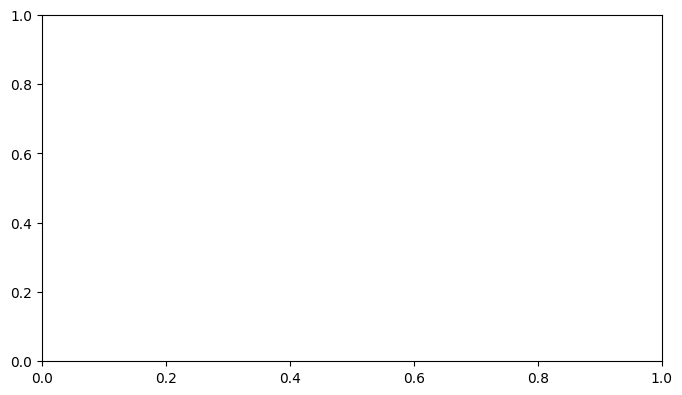

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# Create 'con_adicion' and 'contratos' columns for the annotation from addition_rate_by_value
# 'count' in addition_rate_by_value is the total number of contracts
# 'mean' in addition_rate_by_value is the proportion with additions
# 'porcentaje_con_adicion' is 'mean' * 100

plot_data = addition_rate_by_value.copy()
plot_data['con_adicion'] = (plot_data['mean'] * plot_data['count']).round().astype(int)
plot_data['contratos'] = plot_data['count'].astype(int)

etiquetas = [f"Q{i+1}" for i in range(len(plot_data))]
barras = ax.bar(etiquetas, plot_data["porcentaje_con_adicion"], color="#4C78A8")

# Conteo real sobre cada barra: con adición / total de contratos
for barra, (_, fila) in zip(barras, plot_data.iterrows()):
    ax.annotate(
        f"{int(fila['con_adicion'])} de {int(fila['contratos']):,}",
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha="center", va="bottom", fontsize=9,
        xytext=(0, 3), textcoords="offset points",
    )

ax.set_xlabel("Cuartil de valor del contrato (Q1 = más bajo, Q4 = más alto)")
ax.set_ylabel("% de contratos con adición")
ax.set_title("Frecuencia de adiciones por grupo de valor")
ax.set_ylim(0, plot_data["porcentaje_con_adicion"].max() * 1.3 + 0.01)
plt.tight_layout()
plt.show()

## Asociación no significa causalidad

Cuando dos variables cambian conjuntamente, la relación puede tener varias explicaciones. Una tercera variable puede influir sobre ambas y alterar la interpretación; en estadística se habla de una variable de confusión.

Para este expediente, responda:

1. ¿Qué variable podría estar influyendo en la relación observada?
2. ¿Por qué podría modificar la interpretación?
3. ¿Qué información adicional sería necesaria para comprobarlo?


## Pensar un experimento antes de hablar de causalidad

El análisis de SECOP es observacional: trabaja con contratos que ya ocurrieron. No es un experimento A/B.

Describa una comparación ideal:

1. ¿Cuáles serían los grupos A y B?
2. ¿Qué resultado mediría?
3. ¿Sería viable asignar los grupos al azar?
4. ¿Qué diseño observacional o cuasi-experimental utilizaría si la aleatorización no fuera posible?


### Una aproximación al concepto de potencia

La potencia estadística responde una pregunta práctica: si realmente existe una diferencia de interés entre dos grupos, ¿el tamaño de muestra permite detectarla con una probabilidad razonable?

El siguiente cálculo utiliza una aproximación normal para dos grupos de igual tamaño. El propósito es observar la relación entre tamaño de efecto y tamaño de muestra.


In [ ]:
alpha = 0.05
target_power = 0.80
effect_size = 0.50

normal = NormalDist()
z_alpha = normal.inv_cdf(1 - alpha / 2)
z_power = normal.inv_cdf(target_power)

n_per_group = math.ceil(
    2 * ((z_alpha + z_power) / effect_size) ** 2
)

pd.Series({
    "alpha": alpha,
    "potencia_objetivo": target_power,
    "tamaño_de_efecto_estandarizado": effect_size,
    "n_aproximado_por_grupo": n_per_group,
})


### Antes de terminar

1. Si la diferencia de interés fuera más pequeña, ¿esperaría necesitar más o menos observaciones?
2. ¿Por qué disponer de muchas filas no corrige por sí solo un sesgo o una variable de confusión?
3. ¿Qué limitación de este expediente considera más importante después de completar la segunda semana?


## Actividad entregable

El entregable se construye a partir de la ejecución y el análisis de este notebook.

### Tablero de evidencia

Presente tres tarjetas. Cada una debe contener un hallazgo, la evidencia que lo sustenta, una interpretación posible y una duda pendiente. Las cifras deben poder localizarse en las salidas del notebook.

### Decisiones de preparación

Documente tres decisiones tomadas sobre la preparación de los datos. Para cada una indique el problema encontrado, el tratamiento aplicado, la evidencia que respalda la decisión y qué podría cambiar si esa decisión fuera incorrecta.

### Respuesta a la objeción y veredicto

Explique qué cambió después de incorporar la comparación de la segunda semana. El veredicto final debe ser uno de los siguientes:

- respaldada;
- parcialmente respaldada;
- no respaldada.

La conclusión debe incluir la principal limitación del análisis y una breve recomendación.

### Evidencia causal más fuerte

Explique qué diseño permitiría obtener evidencia causal más fuerte. Si un experimento aleatorizado no es viable, proponga una alternativa observacional o cuasi-experimental y justifique qué variable adicional sería necesario controlar.

### Declaración de uso de herramientas de inteligencia artificial

Indique la herramienta empleada, la actividad en la que se utilizó, el resultado que fue verificado y la forma de verificación, y una decisión del equipo que no se delegó a la herramienta.

El notebook entregado debe ejecutarse de principio a fin y reproducir las cifras utilizadas en el tablero y en el veredicto.
